In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [72]:
df = pd.read_csv(r"C:\Users\VIJAY K G\OneDrive\Documents\VIJAY K G\Python with harry\Python\Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype('float')

#replaced the value 0 where total charges are null or blank space
#changed the data type of total charges str to float

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [73]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

#converted 0 and 1 value of senior citizen to Yes/No for better understanding

Text(0.5, 1.0, 'Count of Customers by Churn')

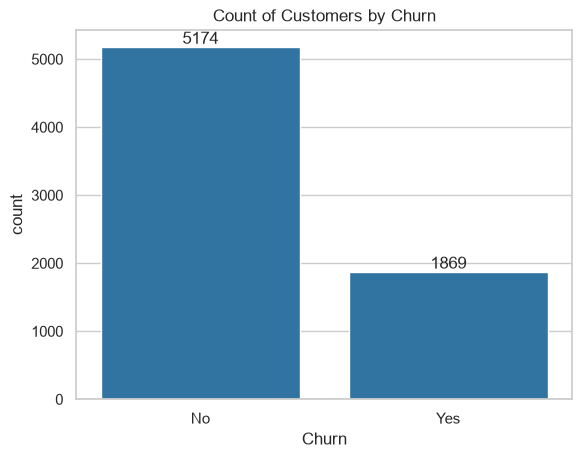

In [66]:
ax = sns.countplot(data=df,
              x='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")

Text(0.5, 1.0, 'Percentage of Churned Customers')

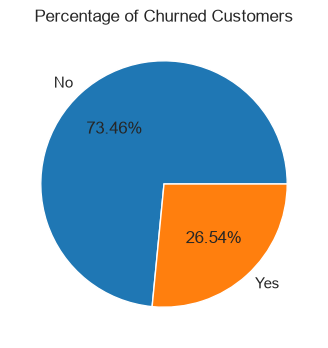

In [67]:
plt.figure(figsize = (4,4))
gb = df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'], 
        labels = gb.index,
        autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers")

Text(0.5, 1.0, 'Churn by Gender')

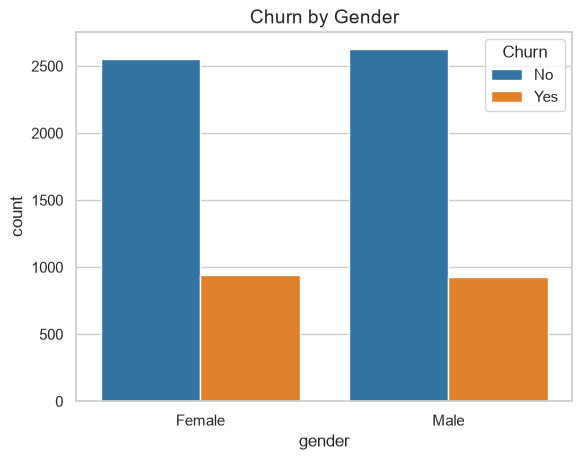

In [93]:
sns.set_style("whitegrid")
sns.set_context("notebook")
sns.countplot(data = df,
              x = "gender",
              hue = "Churn")
plt.title("Churn by Gender", fontsize = 14)

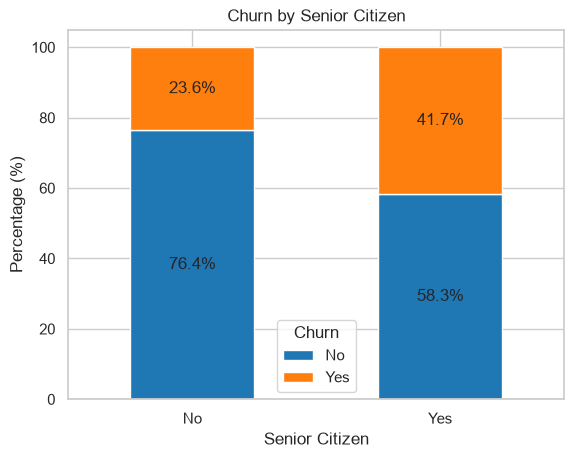

In [88]:
sns.set_style("whitegrid")
sns.set_context("notebook")

percentage = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

ax = percentage.plot(
    kind="bar",
    stacked=True
)

plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.show()

<Axes: xlabel='tenure', ylabel='Count'>

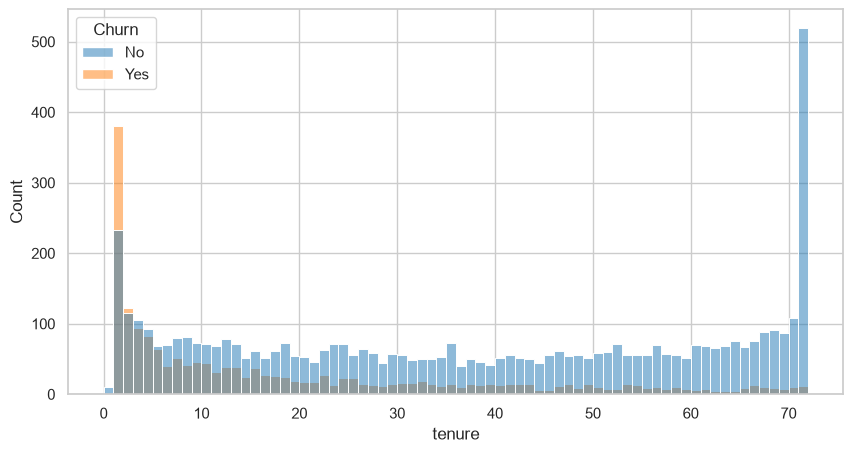

In [140]:
plt.figure(figsize = (10,5))
sns.histplot(data = df,
             x = "tenure",
             hue = "Churn",
             bins = 72)

Text(0.5, 1.0, 'Count Customers by Contract')

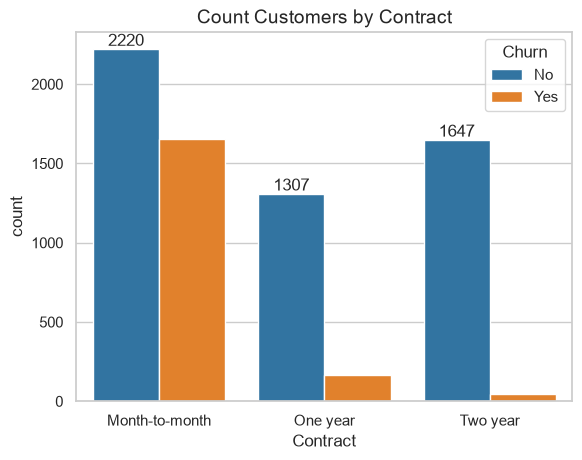

In [144]:
ax = sns.countplot(data = df,
              x = "Contract",
              hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count Customers by Contract", fontsize = 14)

In [145]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

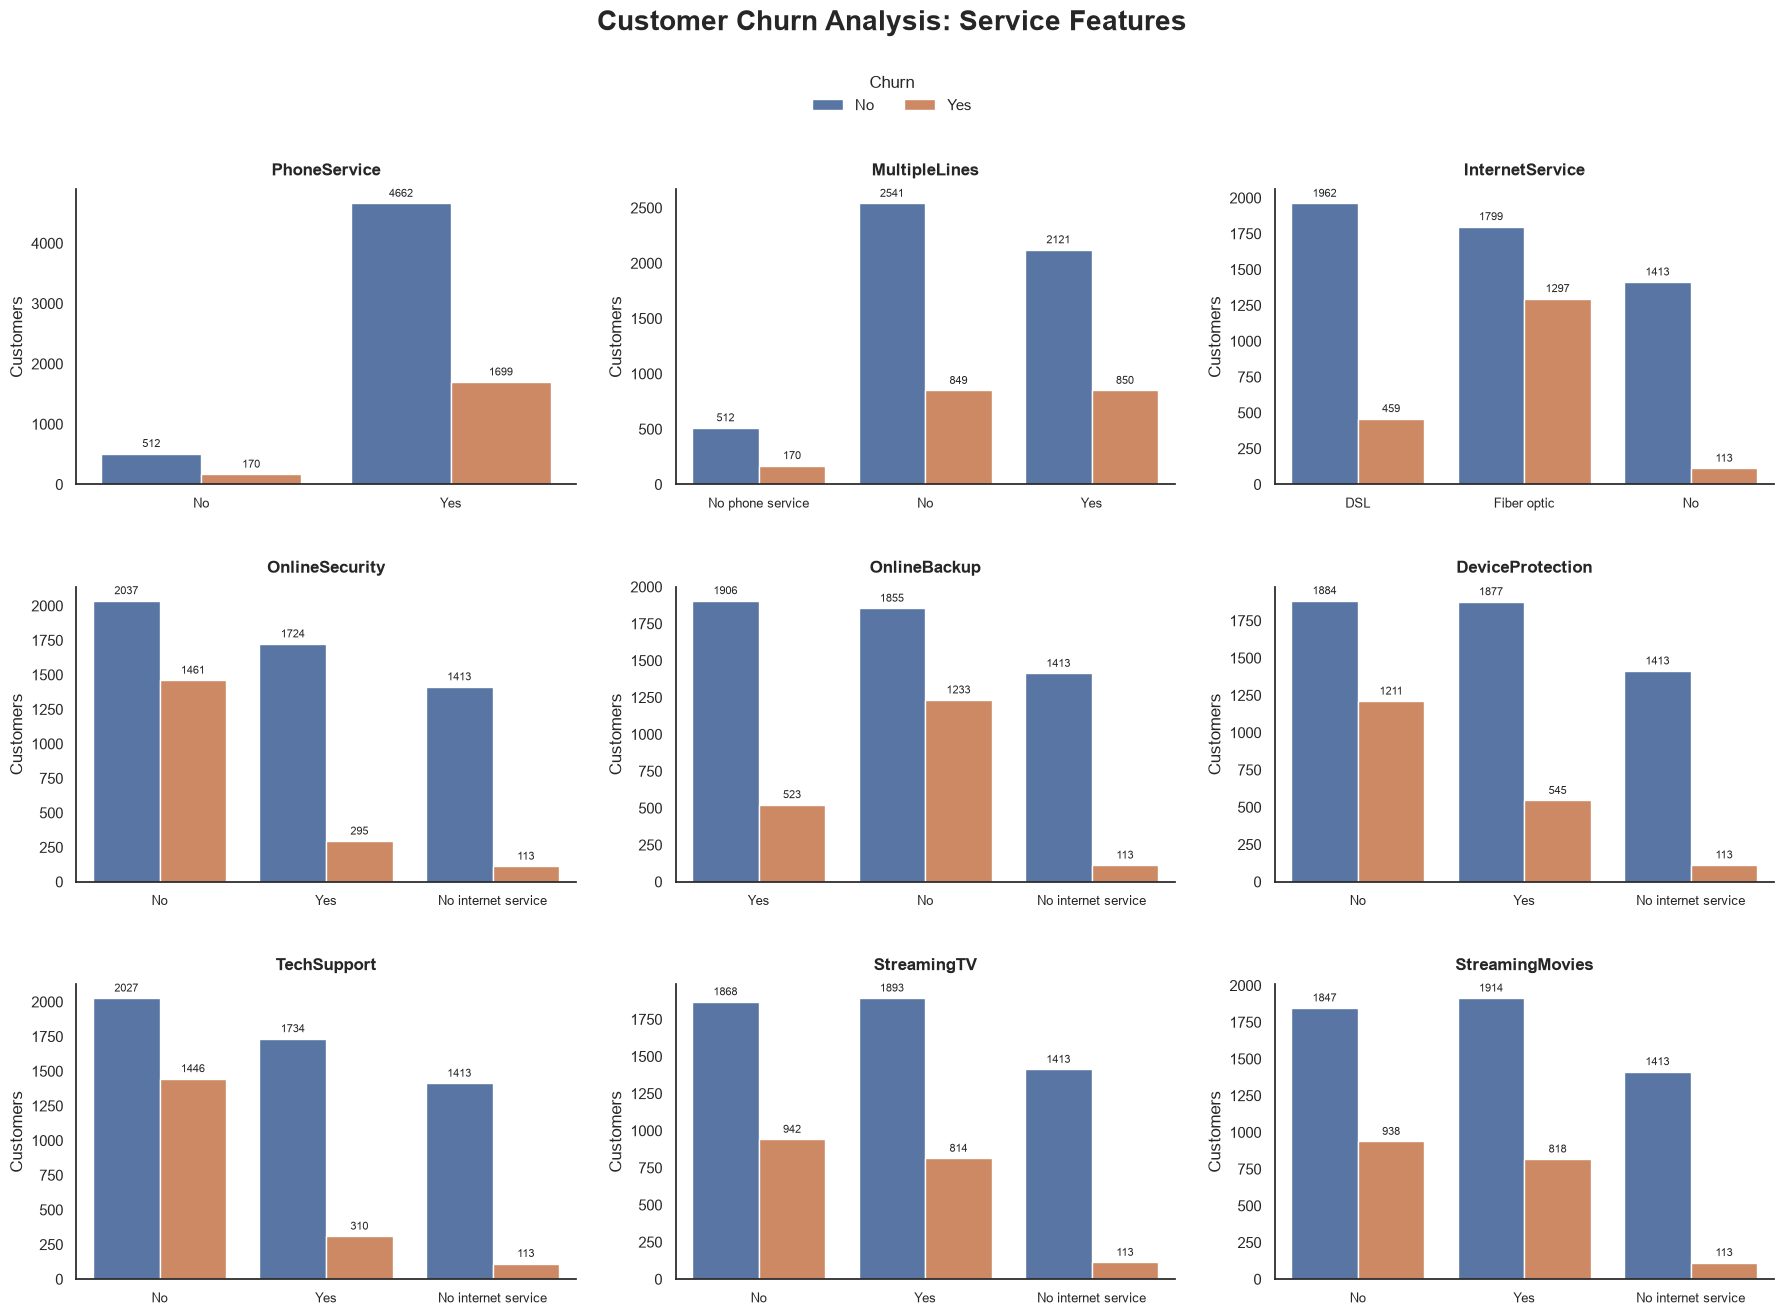

In [157]:
sns.set_theme(style="white")

columns = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fig, axes = plt.subplots(
    3, 3,
    figsize=(18, 13)
)

axes = axes.flatten()

for ax, col in zip(axes, columns):

    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=ax
    )

    # Title
    ax.set_title(
        col,
        fontsize=12,
        fontweight='bold',
        pad=10
    )

    ax.set_xlabel('')
    ax.set_ylabel('Customers')

    # Remove grid/cross lines
    ax.grid(False)

    # Category labels
    ax.tick_params(
        axis='x',
        rotation=0,
        labelsize=9
    )

    # Long labels
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')

    # Add values on bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%d',
            padding=3,
            fontsize=8
        )

    # Remove individual legends
    ax.get_legend().remove()

    # Remove unnecessary borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Churn',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.97),
    ncol=2,
    frameon=False
)

# Main title
fig.suptitle(
    'Customer Churn Analysis: Service Features',
    fontsize=20,
    fontweight='bold',
    y=1.01
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94],
    h_pad=3,
    w_pad=2
)

plt.show()

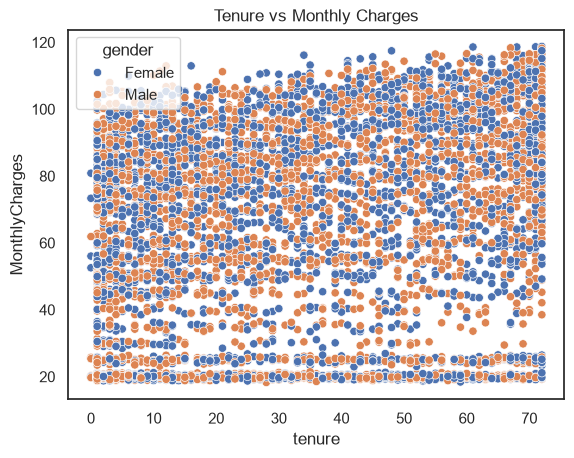

In [167]:
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue= "gender"
)

plt.title('Tenure vs Monthly Charges')
plt.show()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

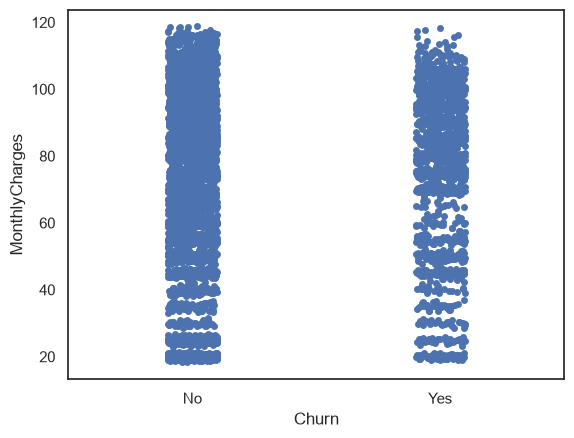

In [165]:
sns.stripplot(
    data=df,
    y='MonthlyCharges',
    x='Churn',
    jitter=True)

<Axes: xlabel='Churn', ylabel='tenure'>

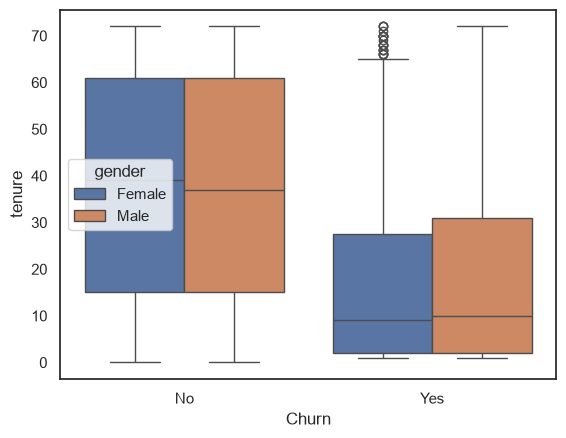

In [162]:
sns.set_context("notebook")
sns.boxplot(data=df,
            x='Churn',
            y='tenure',
            hue = "gender")

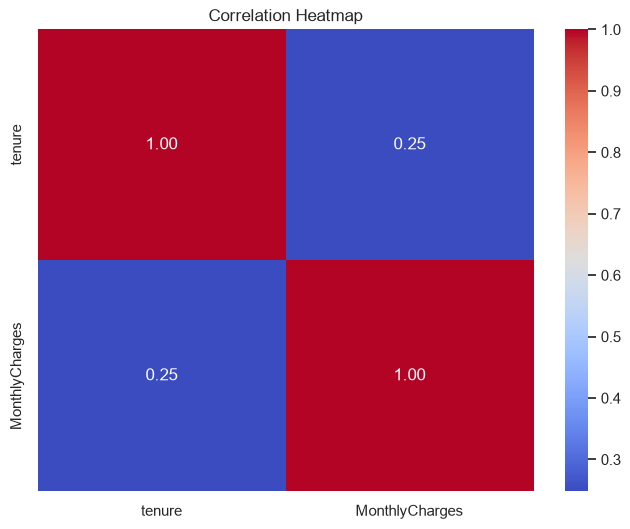

In [168]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()